# Regression Track: Dataset, EDA, and Preprocessing

In [1]:
"""
Imports
"""
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../regression_dataset/hospital-inpatient-discharges-sparcs-de-identified-2010-1.csv",low_memory=False)

In [3]:
target_column = "Length of Stay"

In [4]:
print("Overview of the dataset\n----------------------")
print(f"Shape : {df.shape}\n")
print(f"Datatypes :\n{df.dtypes}\n")
print(f"Missing value counts : \n{df.isnull().sum()}\n")

Overview of the dataset
----------------------
Shape : (2622133, 38)

Datatypes :
index                                    int64
Health Service Area                        str
Hospital County                            str
Operating Certificate Number           float64
Facility ID                            float64
Facility Name                              str
Age Group                                  str
Zip Code - 3 digits                        str
Gender                                     str
Race                                       str
Ethnicity                                  str
Length of Stay                             str
Type of Admission                          str
Patient Disposition                        str
Discharge Year                           int64
CCS Diagnosis Code                     float64
CCS Diagnosis Description                  str
CCS Procedure Code                     float64
CCS Procedure Description                  str
APR DRG Code             

## EDA visualisations

In [5]:
import math
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set_theme(style="whitegrid")

# Target variable
target_column = "Length of Stay"

# Make sure target is numeric
df[target_column] = pd.to_numeric(
    df[target_column],
    errors="coerce"
)

df = df[df[target_column].notna()].copy()

# Separate numeric and categorical features
numeric_features = df.select_dtypes(include="number").columns.tolist()
categorical_features = df.select_dtypes(exclude="number").columns.tolist()

# Remove index-like columns from visualizations
numeric_features = [
    column for column in numeric_features
    if column not in ["index", target_column]
]

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['Operating Certificate Number', 'Facility ID', 'Discharge Year', 'CCS Diagnosis Code', 'CCS Procedure Code', 'APR DRG Code', 'APR MDC Code', 'APR Severity of Illness Code', 'Attending Provider License Number', 'Operating Provider License Number', 'Other Provider License Number', 'Birth Weight', 'Total Charges', 'Total Costs']
Categorical features: ['Health Service Area', 'Hospital County', 'Facility Name', 'Age Group', 'Zip Code - 3 digits', 'Gender', 'Race', 'Ethnicity', 'Type of Admission', 'Patient Disposition', 'CCS Diagnosis Description', 'CCS Procedure Description', 'APR DRG Description', 'APR MDC Description', 'APR Severity of Illness Description', 'APR Risk of Mortality', 'APR Medical Surgical Description', 'Source of Payment 1', 'Source of Payment 2', 'Source of Payment 3', 'Abortion Edit Indicator', 'Emergency Department Indicator']


### 1. Distribution plots for every numeric feature

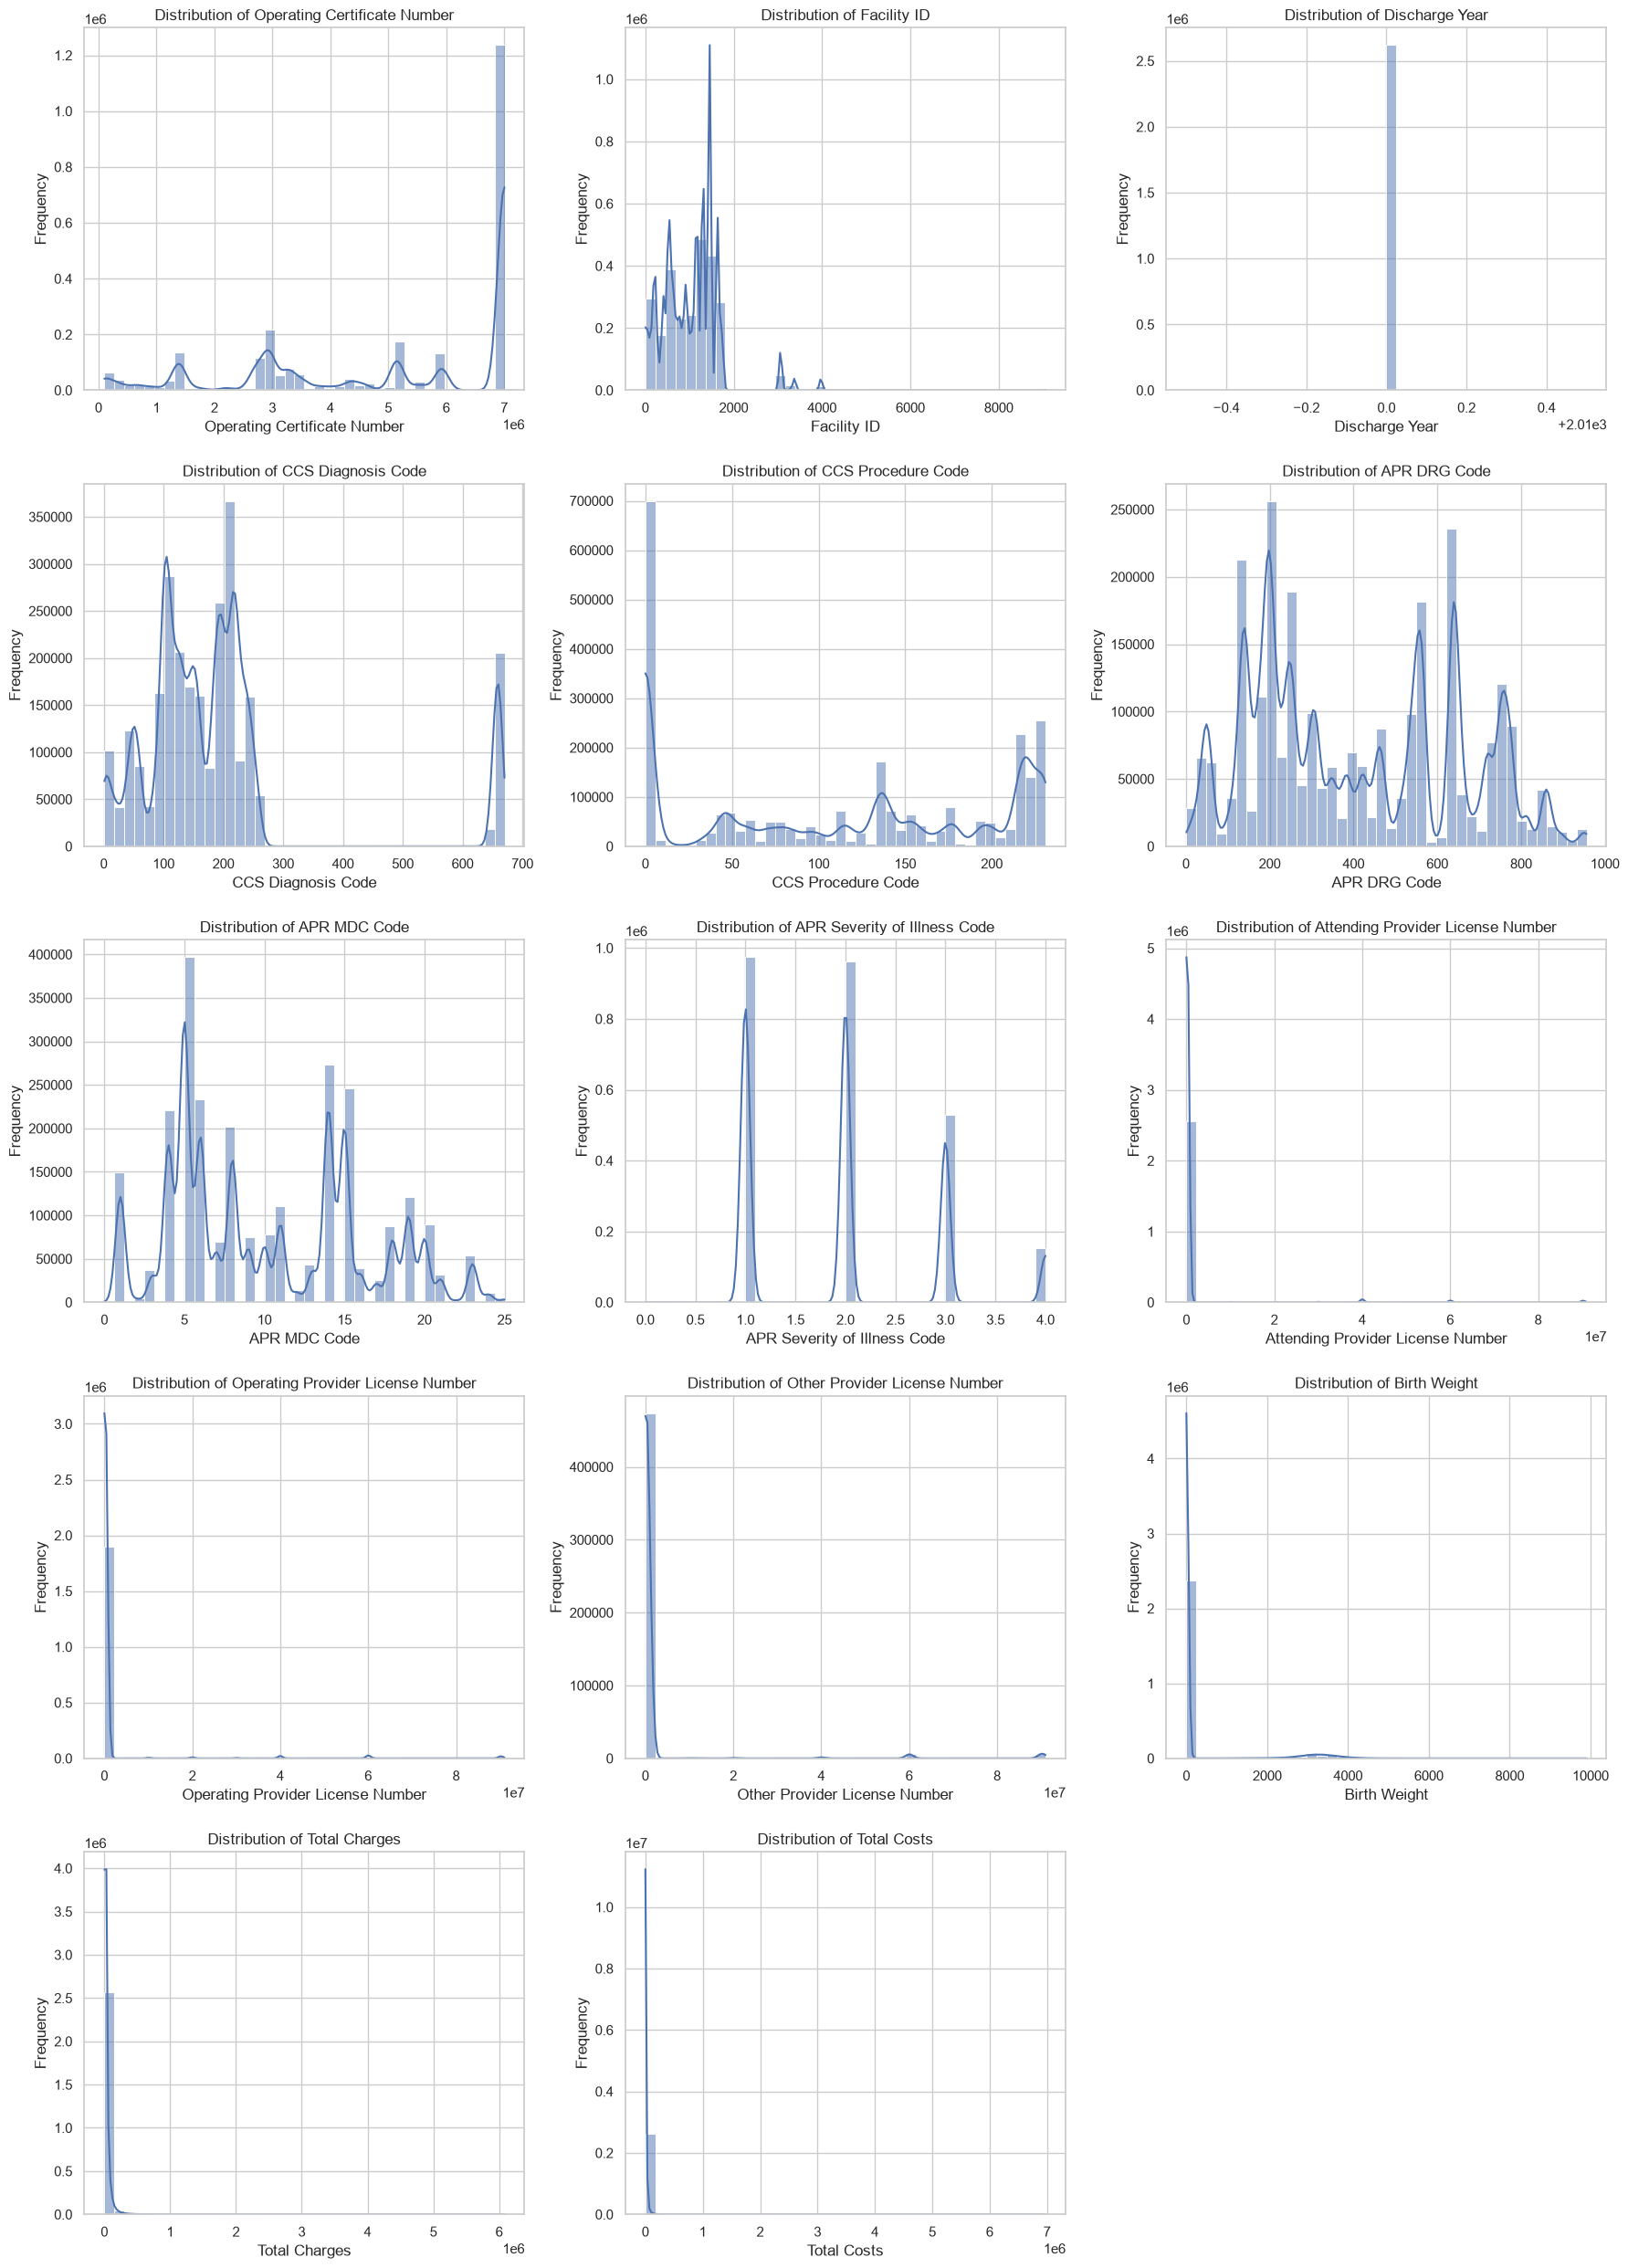

In [6]:
number_of_columns = 3
number_of_rows = math.ceil(len(numeric_features) / number_of_columns)

fig, axes = plt.subplots(
    number_of_rows,
    number_of_columns,
    figsize=(18, 5 * number_of_rows)
)

axes = axes.flatten()

for index, feature in enumerate(numeric_features):
    sns.histplot(
        data=df,
        x=feature,
        bins=40,
        kde=True,
        ax=axes[index]
    )

    axes[index].set_title(f"Distribution of {feature}")
    axes[index].set_xlabel(feature)
    axes[index].set_ylabel("Frequency")

for index in range(len(numeric_features), len(axes)):
    axes[index].set_visible(False)

plt.tight_layout()
plt.show()

## Numeric distributions
The numeric variables are measured on very different scales. Several distributions are right-skewed, especially cost-related or count-like variables, so the median imputation and standard scaling used later are appropriate. The engineered age midpoint should be interpreted as an ordered approximation rather than an exact age.

### 2. Distribution plots for categorical features

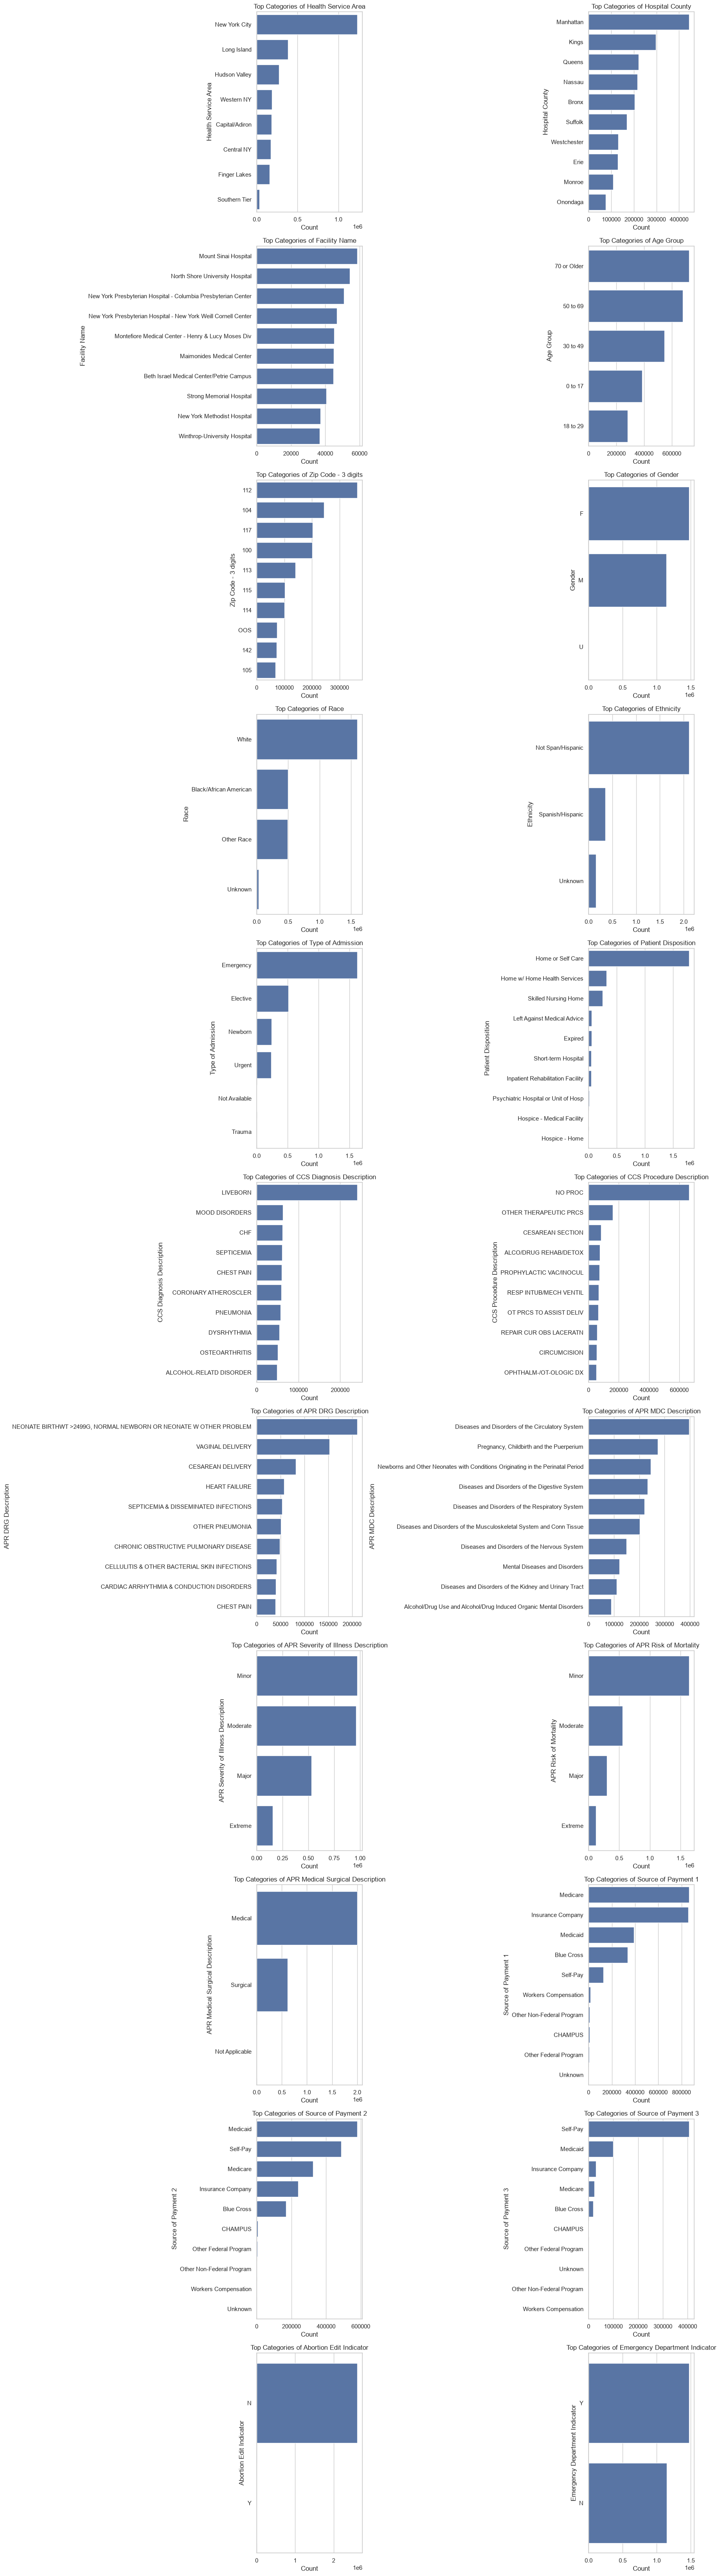

In [7]:
number_of_columns = 2
number_of_rows = math.ceil(len(categorical_features) / number_of_columns)

fig, axes = plt.subplots(
    number_of_rows,
    number_of_columns,
    figsize=(18, 6 * number_of_rows)
)

axes = axes.flatten()

for index, feature in enumerate(categorical_features):
    top_categories = df[feature].value_counts().head(10).index

    plot_data = df[df[feature].isin(top_categories)]

    sns.countplot(
        data=plot_data,
        y=feature,
        order=top_categories,
        ax=axes[index]
    )

    axes[index].set_title(f"Top Categories of {feature}")
    axes[index].set_xlabel("Count")
    axes[index].set_ylabel(feature)

for index in range(len(categorical_features), len(axes)):
    axes[index].set_visible(False)

plt.tight_layout()
plt.show()

## Categorical distributions
The frequency plots show that the categorical variables are not evenly distributed. A small number of categories account for most observations, while rare categories are grouped by the encoder using min_frequency=10 to reduce unstable, high-cardinality features.

### 3. Target distribution

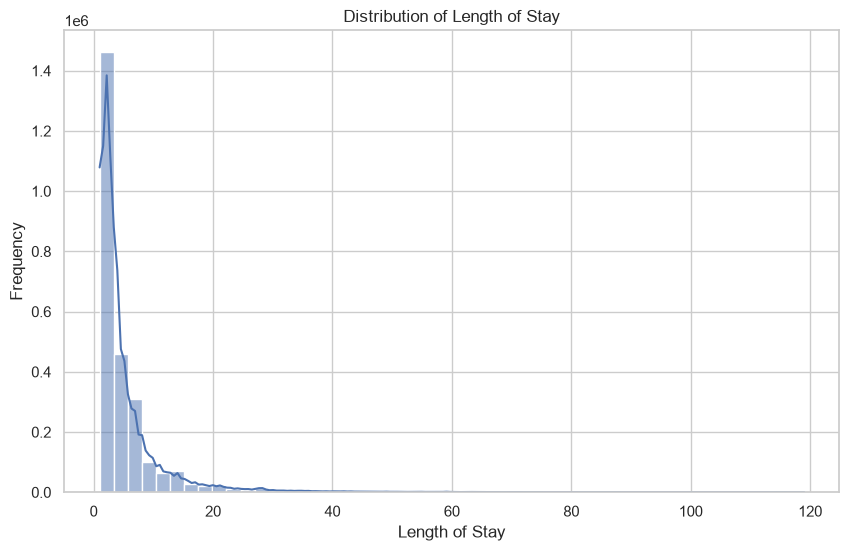

In [8]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x=target_column,
    bins=50,
    kde=True
)

plt.title("Distribution of Length of Stay")
plt.xlabel("Length of Stay")
plt.ylabel("Frequency")
plt.show()

## Target distribution
Length of stay is a non-negative, count-like target and is typically concentrated at shorter stays with a smaller number of long admissions. This skew should be considered when interpreting MAE, RMSE, and any unusually large prediction errors.

### 4. Correlation heatmap

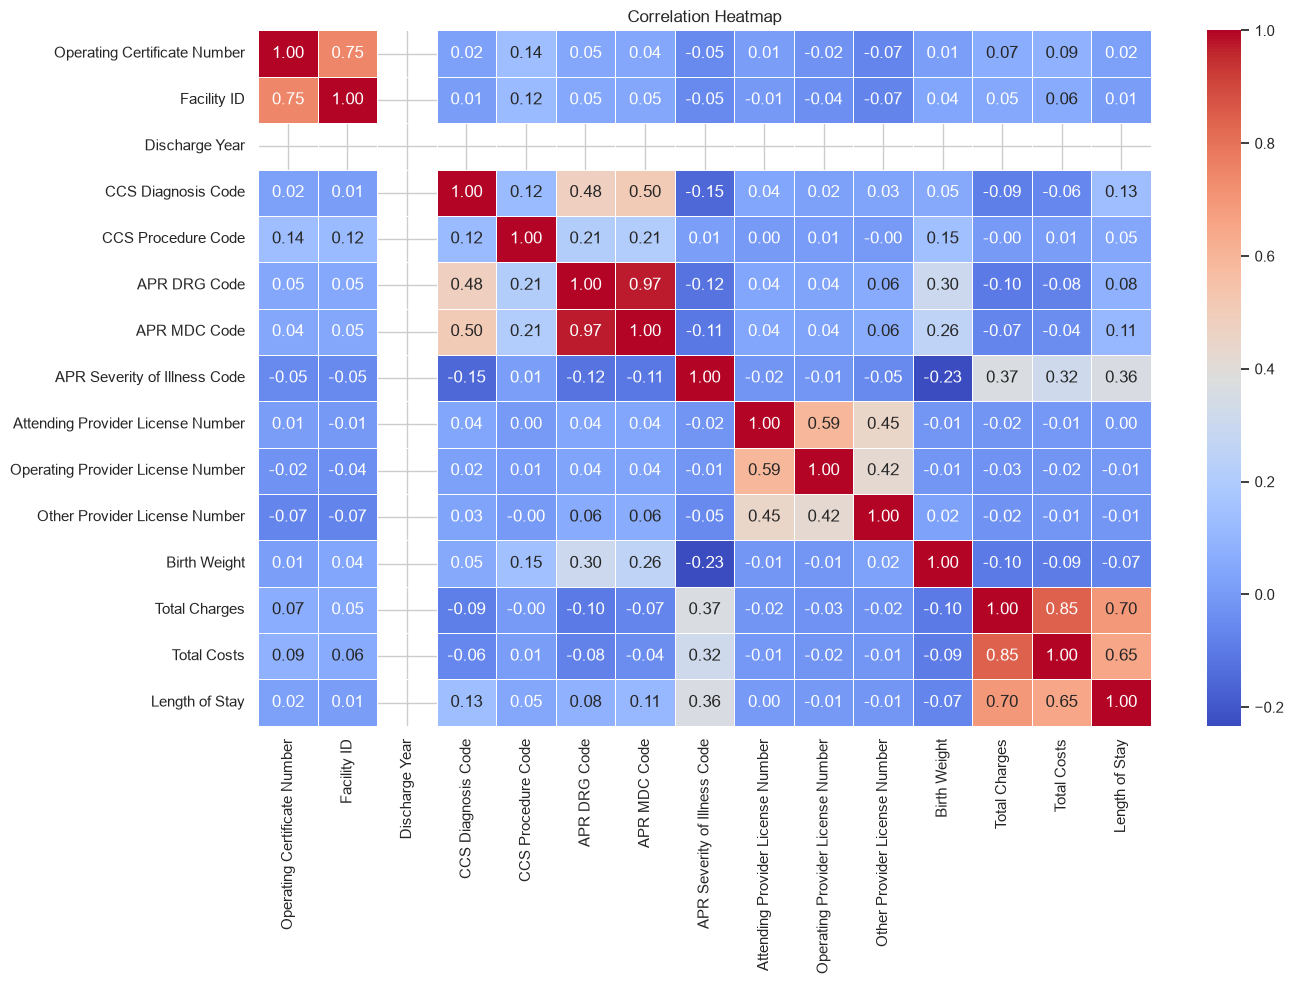

In [9]:
correlation_data = df[
    numeric_features + [target_column]
].corr()

plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation_data,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

## Correlation heatmap
The heatmap compares linear relationships among numeric variables. Strong correlations may indicate redundant information, while weak pairwise correlations do not prove that a feature is unhelpful because categorical and non-linear relationships are not captured by this plot.

### 5. Scatter plots showing feature-target relationships

Selected features: ['Total Charges', 'Total Costs']


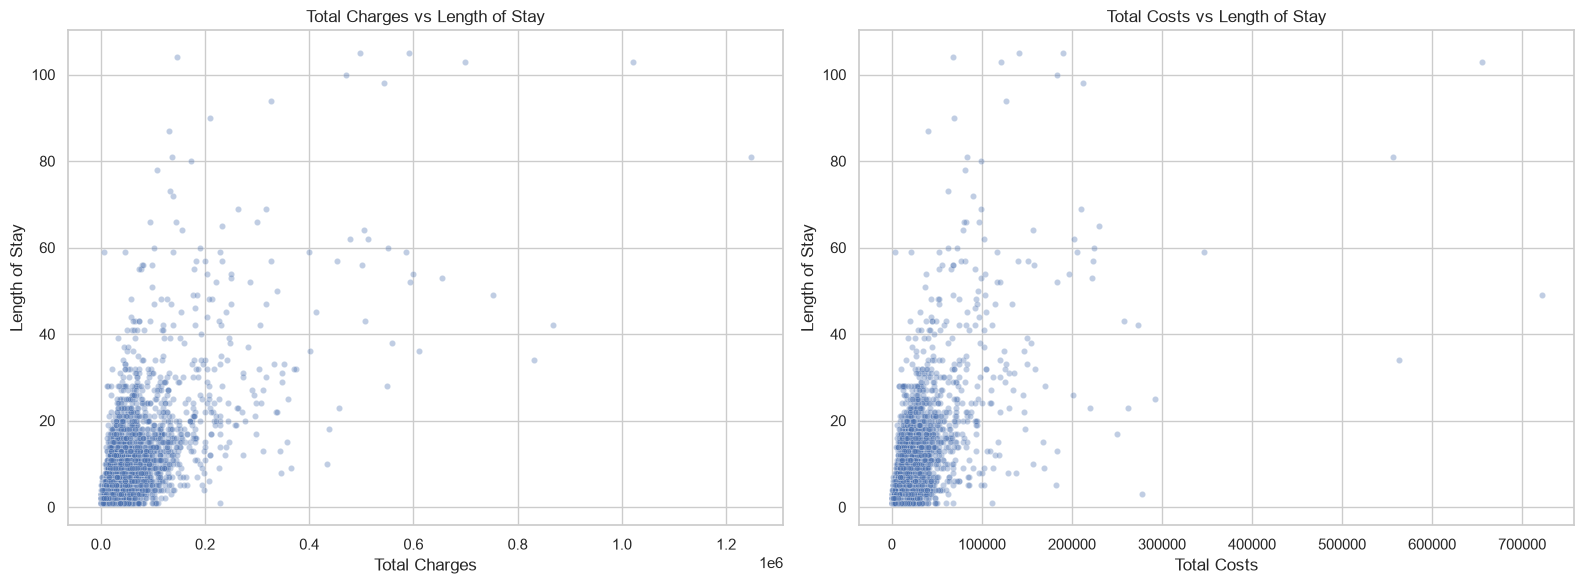

In [10]:
target_correlations = (
    correlation_data[target_column]
    .drop(target_column)
    .abs()
    .sort_values(ascending=False)
)

top_two_features = target_correlations.head(2).index.tolist()

print("Selected features:", top_two_features)
fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 6)
)

for index, feature in enumerate(top_two_features):
    sample_data = df[[feature, target_column]].dropna()

    # Plot a sample for faster visualization
    if len(sample_data) > 10000:
        sample_data = sample_data.sample(
            10000,
            random_state=42
        )

    sns.scatterplot(
        data=sample_data,
        x=feature,
        y=target_column,
        alpha=0.35,
        s=20,
        ax=axes[index]
    )

    axes[index].set_title(
        f"{feature} vs {target_column}"
    )
    axes[index].set_xlabel(feature)
    axes[index].set_ylabel(target_column)

plt.tight_layout()
plt.show()

## Feature target scatter plots
The two selected features have the strongest absolute numeric correlations with length of stay in this dataset. The scatter plots show whether the relationship is approximately linear and whether the spread of errors changes across the target range; dense vertical bands are expected for discrete or coded variables.

In [ ]:
# Convert the target to numeric and remove invalid target rows
df["Length of Stay"] = pd.to_numeric(df["Length of Stay"], errors="coerce")
df[target_column] = pd.to_numeric(df[target_column], errors="coerce")

# Remove exact duplicate rows before splitting the data.
duplicate_count = df.duplicated().sum()
df = df.drop_duplicates().copy()

# Remove rows where the target is missing or invalid.
invalid_target_count = df[target_column].isna().sum()
df = df[df[target_column].notna() & (df[target_column] >= 0)].copy()

# Report extreme target values without silently deleting genuine long stays.
target_upper_limit = df[target_column].quantile(0.995)
extreme_target_count = (df[target_column] > target_upper_limit).sum()

print("Duplicate rows removed:", duplicate_count)
print("Rows with missing target removed:", invalid_target_count)
print("Rows after cleaning:", len(df))
print("99.5th percentile target value:", target_upper_limit)
print("Target values above that threshold:", extreme_target_count)

In [ ]:
# Select features and remove identifiers or target leakage
columns_to_remove = [
    "index",
    "Length of Stay",
    "Total Charges",
    "Total Costs",
    "Operating Certificate Number",
    "Facility ID",
    "Attending Provider License Number",
    "Operating Provider License Number",
    "Other Provider License Number",
]

feature_columns = [column for column in df.columns if column not in columns_to_remove]
X = df[feature_columns].copy()
y = df[target_column].copy()

# Add an ordered numeric representation of the age-group categories.
age_group_midpoints = {
    "0 to 17": 8.5,
    "18 to 29": 23.5,
    "30 to 49": 39.5,
    "50 to 69": 59.5,
    "70 or Older": 80.0,
}
X["Age Group Midpoint"] = X["Age Group"].map(age_group_midpoints)

print("Feature columns:", X.shape[1])
print("Target values:", y.shape[0])
print("Engineered feature added: Age Group Midpoint")

## Feature target scatter plots

In [ ]:
# Treat numeric measurements as numeric and code columns as categories
code_columns = [
    "CCS Diagnosis Code",
    "CCS Procedure Code",
    "APR DRG Code",
    "APR MDC Code",
    "APR Severity of Illness Code",
]

numeric_columns = [
    column
    for column in X_train.select_dtypes(include="number").columns
    if column not in code_columns
]
categorical_columns = [
    column for column in X_train.columns if column not in numeric_columns
]

print("Numeric columns:", numeric_columns)
print("Number of categorical columns:", len(categorical_columns))

In [ ]:
# Fill missing values and convert categories to sparse one-hot columns
numeric_steps = Pipeline([
    ("fill_missing", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
])

categorical_steps = Pipeline([
    ("fill_missing", SimpleImputer(strategy="most_frequent")),
    ("one_hot", OneHotEncoder(
        handle_unknown="ignore",
        min_frequency=10,
        sparse_output=True,
    )),
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_steps, numeric_columns),
    ("categorical", categorical_steps, categorical_columns),
])

X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

print("Encoded training shape:", X_train_encoded.shape)
print("Encoded testing shape:", X_test_encoded.shape)

In [ ]:
# Get the final feature names after preprocessing
all_feature_cols = preprocessor.get_feature_names_out()

print("Number of processed features:", len(all_feature_cols))
print("Processed feature names:")
print(all_feature_cols)

## Feature Engineering
The age-group midpoint gives the regression models a useful ordered approximation of patient age while retaining the original age category as a categorical feature.

In [ ]:
"""
Test train split
"""
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

print("Training Features (X_train):", X_train.shape)
print("Testing Features (X_test):", X_test.shape)
print("Training Target (y_train):", y_train.shape)
print("Testing Target (y_test):", y_test.shape)

assert len(X_train) == len(y_train)
assert len(X_test) == len(y_test)